# Introducció a les sèries temporals

Una sèrie temporal és una seqüència de valors ordenats en el temps. A diferència dels conjunts de dades amb els quals hem treballat als blocs anteriors, on les mostres eren independents entre elles, en una sèrie temporal l'ordre importa: el valor en un instant $t$ depèn dels valors anteriors.


## Conceptes bàsics
A continuació enumerarem els conceptes bàsics que tenim a l'hora de treballar amb sèries temporals:

- Tendència (*trend*): Variació a llarg termini de la sèrie. Pot ser creixent, decreixent o inexistent.

- Estacionalitat (*seasonality*): Patrons que es repeteixen amb una freqüència fixa (diària, mensual, anual...). Per exemple, la temperatura de l'aire és més alta a l'estiu i més baixa a l'hivern de manera sistemàtica.

- Soroll (*noise*): Variació aleatòria que no pot ser explicada per la tendència ni l'estacionalitat.

- Estacionarietat: Una sèrie és estacionària quan la seva mitjana, variància i estructura d'autocorrelació no canvien al llarg del temps. La majoria de models estadístics i de deep learning assumeixen estacionarietat o requereixen que la sèrie sigui transformada per assolir-la. Un model entrenat sobre una sèrie no estacionària pot aprendre patrons que no es repetiran en el futur, donant lloc a prediccions incorrectes.

La majoria de models estadístics de sèries temporals assumeixen que la sèrie es pot descompondre en tendència, estacionalitat i soroll mitjançant addició ($y_t = T_t + S_t + \epsilon_t$) o multiplicació ($y_t = T_t · S_t · \epsilon_t$). El model additiu és adequat quan l'amplitud de l'estacionalitat és constant, mentre que el multiplicatiu és més adequat quan l'estacionalitat creix proporcionalment amb la tendència.


## Mètriques d'avaluació

En problemes de regressió sobre sèries temporals s'utilitzen les mateixes mètriques que en regressió convencional, però cal tenir en compte que les escales temporals i les unitats de mesura influeixen en la seva interpretació.

- Mean Absolute Error (MAE): error mitjà en les unitats originals, és robusta davant outliers i és fàcil d'interpretar. $\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$.

- Root Mean Squared Error (RMSE): penalitza els errors grans més que el MAE. Mateixa unitat que la variable objectiu. $\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$.

- Mean Absolute Percentage Error (MAPE): error en percentatge, independent de l'escala. Útil per comparar models sobre sèries amb magnituds molt diferents. Problemàtica quan $y_i \approx 0$. $\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$.

L'elecció de la mètrica depèn del context del problema. El MAE és la opció més intuïtiva quan es vol una interpretació directa de l'error en les unitats originals. El RMSE és més adequat quan els errors grans són especialment indesitjables, ja que els penalitza de manera quadràtica. Finalment, el MAPE és útil quan es vol comparar el rendiment de models sobre datasets o escales diferents, ja que expressa l'error en percentatge i és independent de la magnitud de la variable objectiu.

En problemes de classificació emprarem les mètriques em emprat en els dos mòduls anteriors.


## Models clàssics amb `statsmodels`

Abans de les xarxes neuronals, els models estadístics han estat la referència per treballar amb sèries temporals. La llibreria `statsmodels` té un mòdul anomenat *Time Series Analysis* que implementa els més habituals i és un bon punt de partida per entendre l'estructura de les dades. Encara que en aquest curs no emprarem aquesta llibreria la seva facilitat d'ús comparable amb `scikit-learn` pot ser d'interès.

Enllaç a [statsmodels](https://www.statsmodels.org/stable/user-guide.html#time-series-analysis).

A continuació trobarem alguns exemples d'ús que ens serveixen per entendre el seu funcionament:


### Exemple

En aquest exemple usarem el dataset **Air Passengers** de `statsmodels`, que conté el nombre mensual de passatgers d'aviació als Estats Units entre 1949 i 1960. És un exemple clàssic de sèrie temporal amb tendència creixent i estacionalitat anual clara.


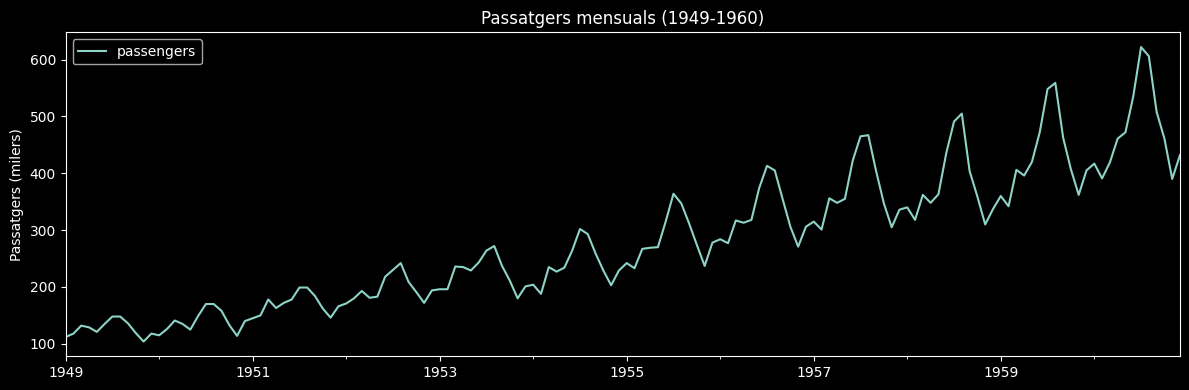

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Càrrega del dataset
data = sm.datasets.get_rdataset("AirPassengers", "datasets").data
data.columns = ['time', 'passengers']
data.index = pd.date_range(start='1949-01', periods=len(data), freq='ME')
data = data[['passengers']]

# Visualització
data.plot(figsize=(12, 4), title='Passatgers mensuals (1949-1960)')
plt.ylabel('Passatgers (milers)')
plt.tight_layout()
plt.show()

### Rolling mean
La mitjana mòbil suavitza la sèrie calculant la mitjana dels últims $k$ valors. És útil per visualitzar la tendència i eliminar el soroll.

$$\hat{y}_t = \frac{1}{k} \sum_{i=0}^{k-1} y_{t-i}$$

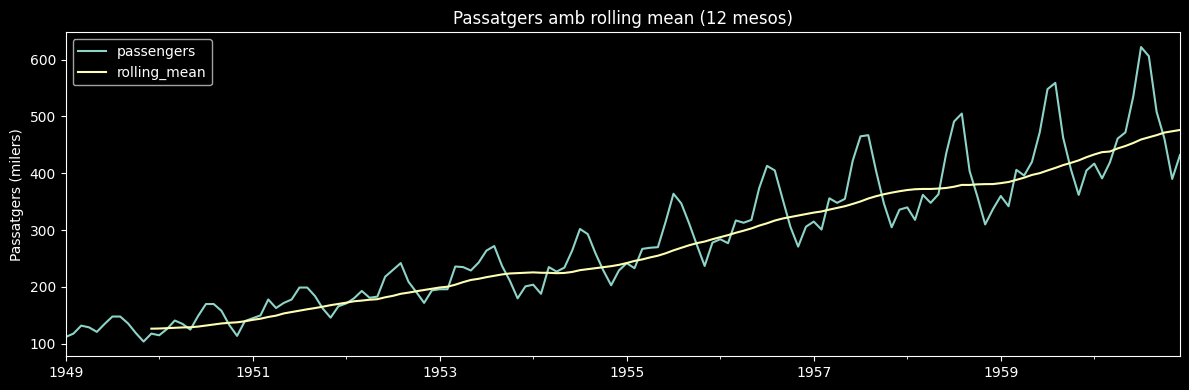

In [2]:
# Rolling mean amb finestra de 12 mesos
data['rolling_mean'] = data['passengers'].rolling(window=12).mean()

data.plot(figsize=(12, 4), title='Passatgers amb rolling mean (12 mesos)')
plt.ylabel('Passatgers (milers)')
plt.tight_layout()
plt.show()

### Descomposició de la sèrie

`statsmodels` permet descompondre la sèrie en tendència, estacionalitat i soroll:

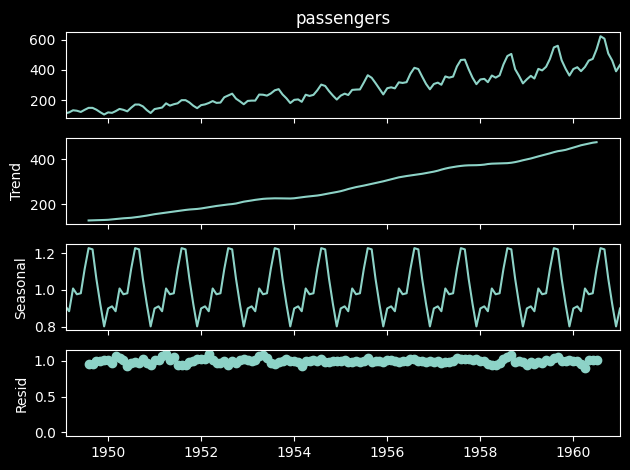

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(data['passengers'], model='multiplicative')
decomposition.plot()
plt.tight_layout()
plt.show()


### Model ARIMA

Ara veurem com aplicar ARIMA (*AutoRegressive Integrated Moving Average*) és un model estadístic clàssic que combina tres components:

- **AR (AutoRegressive):** la predicció depèn dels valors passats de la sèrie.
- **I (Integrated):** diferenciació de la sèrie per assolir estacionarietat.
- **MA (Moving Average):** la predicció depèn dels errors passats del model.

S'especifica amb tres paràmetres $(p, d, q)$: ordre autoregressor, grau de diferenciació i ordre de la mitjana mòbil.

- $p$ és l'ordre autoregressor (AR): Indica quants valors passats de la sèrie s'usen per fer la predicció. Un valor p=2 significa que la predicció en t depèn dels valors en $t−1$ i $t−2$. Valors típics: entre 0 i 5. Un $p=0$ elimina el component autoregressor.

- $d$ és el grau de diferenciació (I): Indica quantes vegades s'ha de diferenciar la sèrie per assolir estacionarietat. Diferenciar significa calcular $y_t - y_{t-1}$, és a dir, treballar amb les variacions en lloc dels valors absoluts. Un valor $d=0$ significa que la sèrie ja és estacionària, $d=1$ és el cas més habitual, i rarament cal anar més enllà de $d=2$.

- $q$ és l' ordre de la mitjana mòbil (MA): Indica quants errors de predicció passats s'incorporen al model. Un valor $q=2$ significa que la predicció en $t$ té en compte els errors comesos en $t−1$ i $t−2$. Valors típics: entre 0 i 5. Un $q=0$ elimina el component de mitjana mòbil.


MAE:  63.55
RMSE: 82.51
MAPE: 14.22%


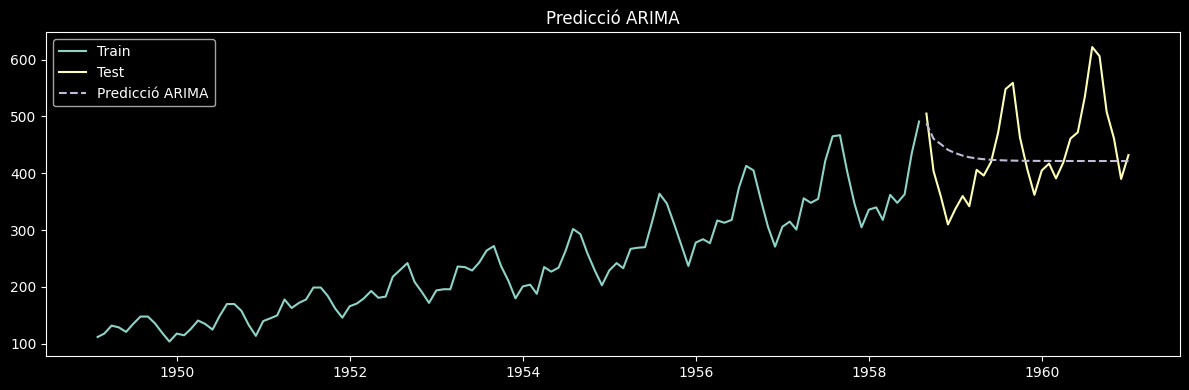

In [9]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np

# Divisió train/test (80/20)
train = data['passengers'][:int(len(data) * 0.8)]
test  = data['passengers'][int(len(data) * 0.8):]

# Entrenament del model ARIMA(2,1,2)
model = ARIMA(train, order=(2, 1, 2))
result = model.fit()

# Predicció
predictions = result.forecast(steps=len(test))

# Avaluació
mae  = mean_absolute_error(test, predictions)
rmse = np.sqrt(np.mean((test.values - predictions.values) ** 2))
mape = np.mean(np.abs((test.values - predictions.values) / test.values)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Visualització
plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, predictions, label='Predicció ARIMA', linestyle='--')
plt.legend()
plt.title('Predicció ARIMA')
plt.tight_layout()
plt.show()

## ML clàssic aplicat a sèries temporals

Els models dels dos primers blocs del curs (Random Forest, SVM, MLP) no estan dissenyats per a sèries temporals, però es poden adaptar mitjançant una tècnica anomenada **sliding window** (finestra lliscant): es transforma la sèrie en un problema de regressió convencional generant, per a cada instant $t$, un vector de features amb els $k$ valors anteriors de la manera següent: $[y_{t-k}, y_{t-k+1}, \ldots, y_{t-1}] \rightarrow \hat{y}_t$.

In [ ]:
import numpy as np

def create_sliding_window(series, window_size):
    X, y = [], []
    for i in range(window_size, len(series)):
        X.append(series[i-window_size:i])
        y.append(series[i])
    return np.array(X), np.array(y)

values = data['passengers'].values
X, y = create_sliding_window(values, window_size=12)

Tot i que l'enfocament de sliding window permet aplicar models clàssics de ML a sèries temporals, té una limitació important: la partició train/test no es pot fer de manera aleatòria com als blocs anteriors, ja que barrejar dades futures amb passades durant l'entrenament introduiria informació que el model no podria tenir disponible en un cas real. Per aquest motiu, la divisió sempre s'ha de fer de manera seqüencial, respectant l'ordre temporal de les dades.